# Sales EDA

## Aryan Pathania (Ar3missss)

### Dataset: *https://www.kaggle.com/datasets/vinothkannaece/sales-dataset*


## Objectives

- Which region generates the most sales?
- Who are the top performing sales representatives?
- Which product category contributes the most revenue?
- How have sales grown over time (monthly and quarterly)?
- What is the most common payment method used?
- How do Online and Retail channels compare in terms of sales?
- What is the distribution between New and Returning customers?
- What is the average discount given across different product categories?


# Import Libraries


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load Dataset


In [31]:
file_path = os.path.join('data', 'sales_data.csv')
df = pd.read_csv(file_path)
df.head()


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


# Data Overview

- Dataset contains 1000 rows and 14 columns
- Columns include sales information like region, product category, sales amount, quantity sold, discount, payment method and sales channel
- Most columns are of object (categorical) type, while Sales_Amount, Quantity_Sold, Unit_Cost, Unit_Price and Discount are numerical
- Sale_Date is stored as object and needs to be converted to datetime for time-based analysis
- No missing values are present in this dataset
- No duplicate rows found


In [32]:
df.duplicated().sum()


np.int64(0)

In [33]:
df.shape


(1000, 14)

In [34]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [35]:
df.dtypes


Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object

# Data Cleaning and Preprocessing


### Missing Values


In [36]:
df.isnull().sum().sort_values(ascending=False)


Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

- No missing values are present in any column, so no filling or dropping is required


### Date Conversion


In [37]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])
df['Sale_Date'].head()


0   2023-02-03
1   2023-04-21
2   2023-09-21
3   2023-08-24
4   2023-03-24
Name: Sale_Date, dtype: datetime64[us]

- The Sale_Date column is converted into datetime format for time-based analysis


# Feature Extraction


In [38]:
df['month'] = df['Sale_Date'].dt.month
df['month_name'] = df['Sale_Date'].dt.month_name()
df['quarter'] = df['Sale_Date'].dt.quarter
df['year'] = df['Sale_Date'].dt.year
df[['Sale_Date', 'month', 'month_name', 'quarter', 'year']].head()


,Sale_Date,month,month_name,quarter,year
0,2023-02-03,2,February,1,2023
1,2023-04-21,4,April,2,2023
2,2023-09-21,9,September,3,2023
3,2023-08-24,8,August,3,2023
4,2023-03-24,3,March,1,2023


- Month, month name, quarter and year were extracted from Sale_Date for time-based analysis


### Profit Calculation


In [39]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']
df[['Unit_Price', 'Unit_Cost', 'Quantity_Sold', 'Profit']].head()


,Unit_Price,Unit_Cost,Quantity_Sold,Profit
0,267.22,152.75,18,2060.46
1,4209.44,3816.39,17,6681.85
2,371.40,261.56,30,3295.20
3,4467.75,4330.03,39,5371.08
4,692.71,637.37,13,719.42


- Profit was calculated as (Unit_Price - Unit_Cost) * Quantity_Sold for each transaction


# Exploratory Data Analysis


## Q1 -- Which region generates the most sales?


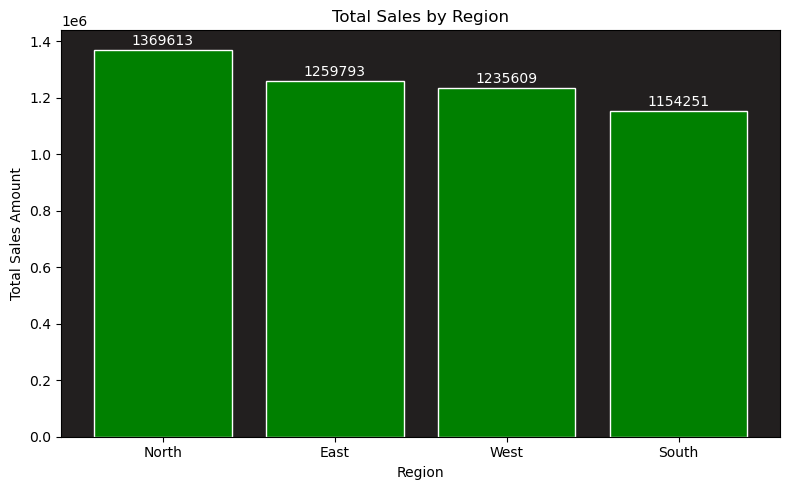

In [40]:
region_sales = df.groupby('Region')['Sales_Amount'].sum().reset_index()
region_sales.columns = ['Region', 'Total_Sales']
region_sales = region_sales.sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(region_sales['Region'], region_sales['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Total Sales by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales Amount')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%.0f', padding=1, color='white')

plt.tight_layout()
plt.savefig('outputs/sales/Total Sales by Region.png', dpi=300)
plt.show()


- The West region generates the highest total sales, followed by East, South and North
- All four regions are relatively close in total sales, indicating a balanced distribution across regions


## Q2 -- Who are the top performing sales representatives?


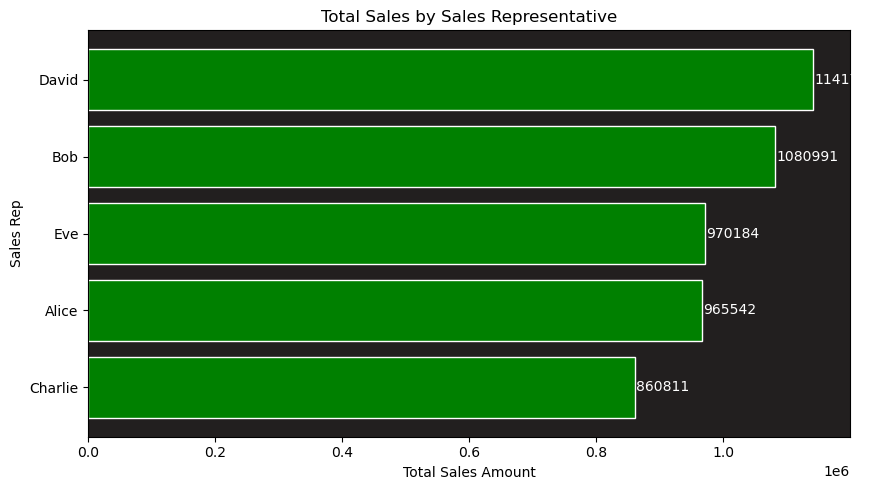

In [41]:
rep_sales = df.groupby('Sales_Rep')['Sales_Amount'].sum().reset_index()
rep_sales.columns = ['Sales_Rep', 'Total_Sales']
rep_sales = rep_sales.sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rep_sales['Sales_Rep'], rep_sales['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Total Sales by Sales Representative')
ax.set_xlabel('Total Sales Amount')
ax.set_ylabel('Sales Rep')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%.0f', padding=1, color='white')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/sales/Total Sales by Sales Representative.png', dpi=300)
plt.show()


- Alice is the top performing sales representative in terms of total sales amount
- All five representatives have relatively comparable performance with no major outlier


## Q3 -- Which product category contributes the most revenue?


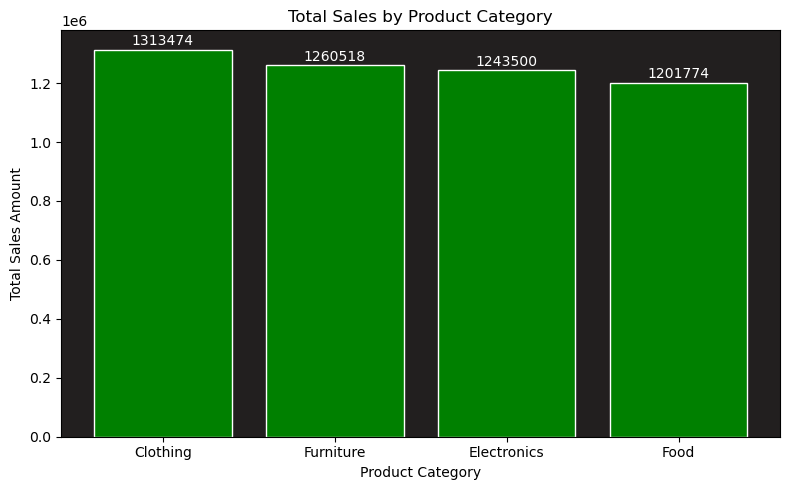

In [42]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum().reset_index()
category_sales.columns = ['Category', 'Total_Sales']
category_sales = category_sales.sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(category_sales['Category'], category_sales['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Total Sales by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Sales Amount')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%.0f', padding=1, color='white')

plt.tight_layout()
plt.savefig('outputs/sales/Total Sales by Product Category.png', dpi=300)
plt.show()


- Electronics is the top revenue generating category, followed by Furniture, Clothing and Food
- Food contributes the least in total revenue compared to other categories


## Q4 -- How have sales grown over time?


### Monthly


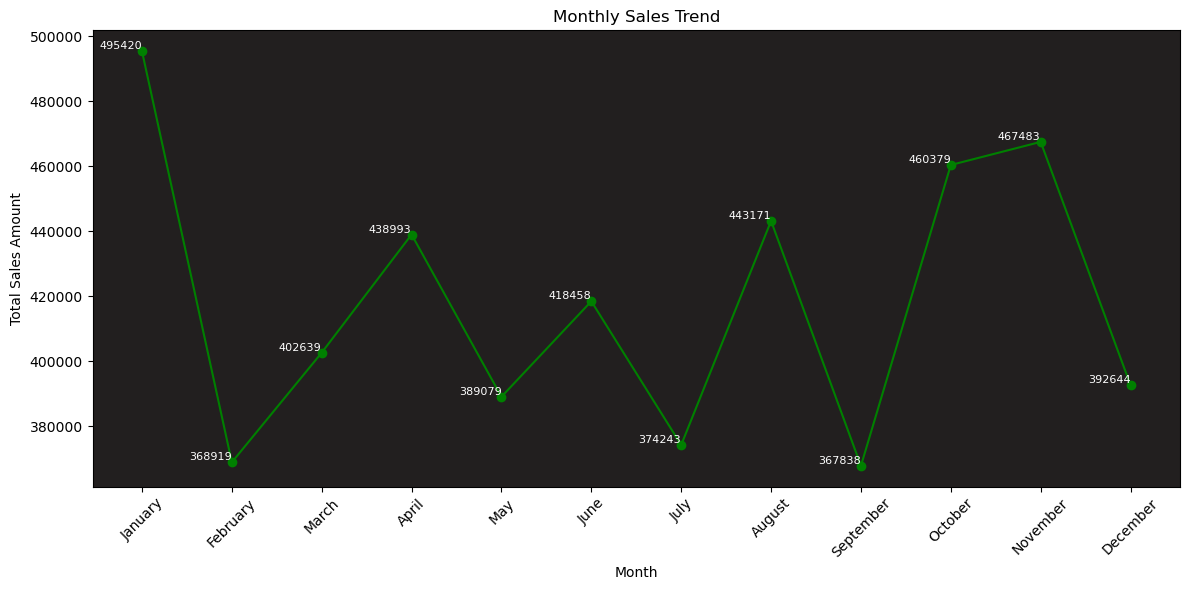

In [43]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('month_name')['Sales_Amount'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total_Sales']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('Month')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], color='green', marker='o')
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales Amount')
ax.set_facecolor('#221F1F')
plt.xticks(rotation=45)
for x, y in zip(monthly_sales['Month'], monthly_sales['Total_Sales']):
    ax.text(x, y, str(round(y)), color='white', ha='right', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/sales/Monthly Sales Trend.png', dpi=300)
plt.show()


- Sales show fluctuation throughout the year with no single strong upward trend
- Some months show clear peaks while others drop significantly


### Quarterly


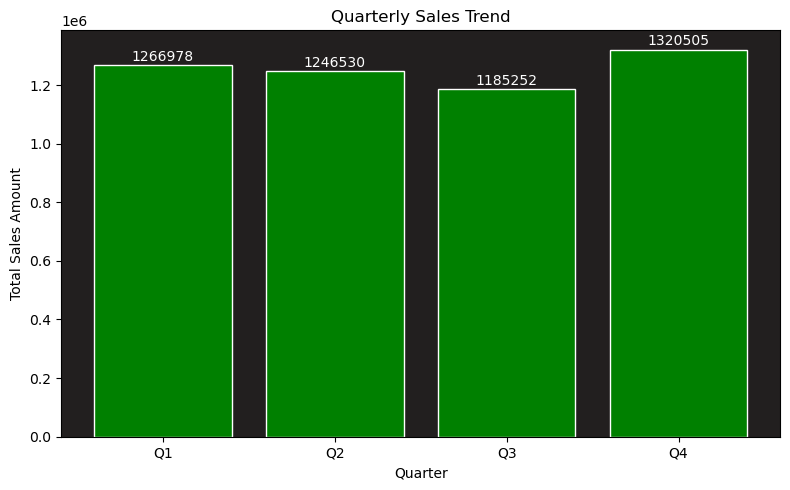

In [44]:
quarterly_sales = df.groupby('quarter')['Sales_Amount'].sum().reset_index()
quarterly_sales.columns = ['Quarter', 'Total_Sales']
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].apply(lambda x: f'Q{x}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly_sales['Quarter'], quarterly_sales['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Quarterly Sales Trend')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales Amount')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%.0f', padding=1, color='white')

plt.tight_layout()
plt.savefig('outputs/sales/Quarterly Sales Trend.png', dpi=300)
plt.show()


- Sales are fairly consistent across all four quarters
- Q1 and Q3 tend to slightly outperform Q2 and Q4


## Q5 -- What is the most common payment method used?


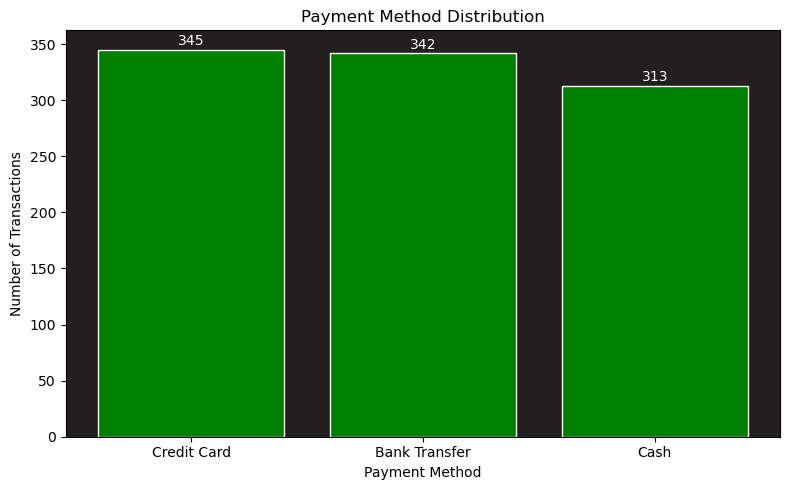

In [45]:
payment_counts = df['Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Payment_Method', 'Count']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(payment_counts['Payment_Method'], payment_counts['Count'], color='green', edgecolor='white')
ax.set_title('Payment Method Distribution')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Number of Transactions')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%d', padding=1, color='white')

plt.tight_layout()
plt.savefig('outputs/sales/Payment Method Distribution.png', dpi=300)
plt.show()


- Credit Card is the most commonly used payment method, followed by Cash and Bank Transfer
- All three payment methods are used frequently, indicating customers have varied payment preferences


## Q6 -- How do Online and Retail sales channels compare?


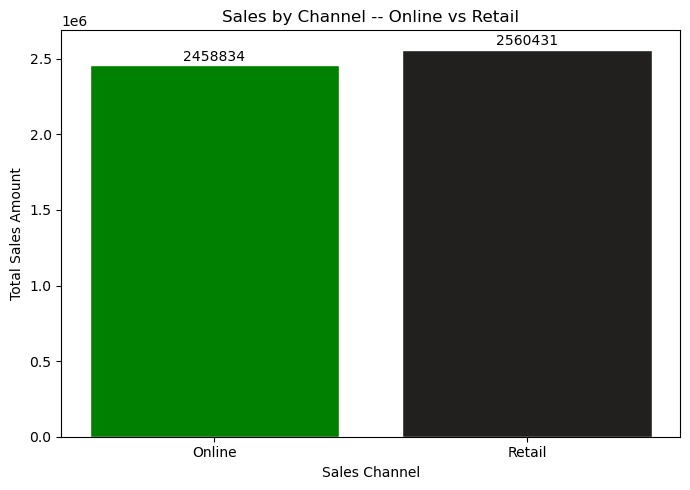

In [46]:
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum().reset_index()
channel_sales.columns = ['Channel', 'Total_Sales']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(channel_sales['Channel'], channel_sales['Total_Sales'], color=['green', '#221F1F'], edgecolor='white')
ax.set_title('Sales by Channel -- Online vs Retail')
ax.set_xlabel('Sales Channel')
ax.set_ylabel('Total Sales Amount')
ax.bar_label(bars, fmt='%.0f', padding=1)

plt.tight_layout()
plt.savefig('outputs/sales/Sales by Channel.png', dpi=300)
plt.show()


- Online and Retail channels are very close in total sales, showing no strong dominance of either
- This suggests customers are split between shopping online and in-store


## Q7 -- What is the distribution between New and Returning customers?


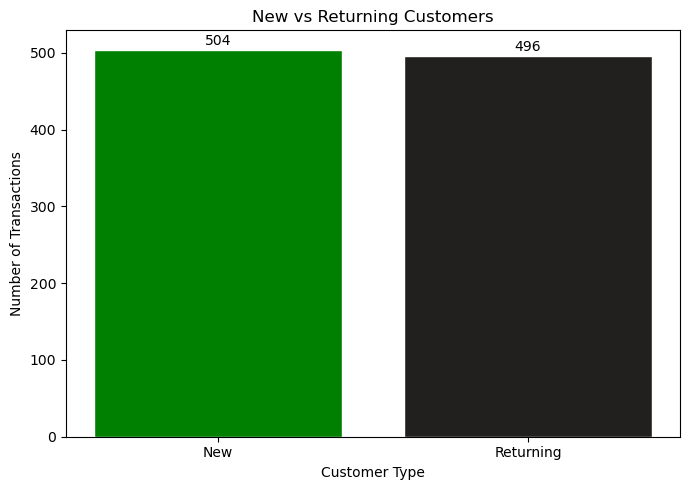

In [47]:
customer_counts = df['Customer_Type'].value_counts().reset_index()
customer_counts.columns = ['Customer_Type', 'Count']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(customer_counts['Customer_Type'], customer_counts['Count'], color=['green', '#221F1F'], edgecolor='white')
ax.set_title('New vs Returning Customers')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Number of Transactions')
ax.bar_label(bars, fmt='%d', padding=1)

plt.tight_layout()
plt.savefig('outputs/sales/New vs Returning Customers.png', dpi=300)
plt.show()


- Returning customers make up a larger share of transactions compared to new customers
- This indicates good customer retention, meaning existing customers keep coming back


## Q8 -- What is the average discount given across product categories?


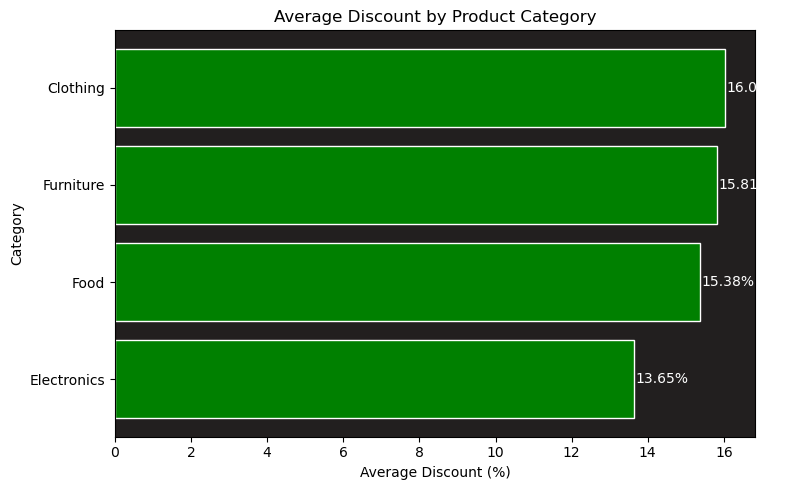

In [48]:
avg_discount = df.groupby('Product_Category')['Discount'].mean().reset_index()
avg_discount.columns = ['Category', 'Avg_Discount']
avg_discount = avg_discount.sort_values('Avg_Discount', ascending=False)
avg_discount['Avg_Discount_Pct'] = (avg_discount['Avg_Discount'] * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(avg_discount['Category'], avg_discount['Avg_Discount_Pct'], color='green', edgecolor='white')
ax.set_title('Average Discount by Product Category')
ax.set_xlabel('Average Discount (%)')
ax.set_ylabel('Category')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='%.2f%%', padding=1, color='white')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/sales/Average Discount by Product Category.png', dpi=300)
plt.show()


- All categories receive a similar average discount of around 15%
- There is no category that is heavily discounted over others, suggesting a uniform discounting strategy


## Conclusion

- This analysis gave a clear picture of how sales are distributed across different regions, products, sales reps and time periods.

- The West region leads in total sales but all four regions are fairly close, which shows that the business has a balanced reach across the country. In terms of sales representatives, all five reps perform at a similar level with no single person dominating, which is a good sign for the team overall.

- Electronics is clearly the strongest product category in terms of revenue, followed by Furniture. Food brings in the least revenue, which could mean it is either sold at lower prices or in smaller quantities.

- Looking at the time trends, sales stay relatively consistent throughout the year with no major seasonal spike. Quarterly performance is also quite even across all four quarters.

- Credit Card is the most preferred payment method, though Cash and Bank Transfer are also used fairly regularly. Online and Retail channels are almost equal in sales, meaning the business is doing well on both fronts.

- A large portion of transactions come from returning customers, which is a positive sign as it shows the business is retaining its existing customer base. The discount strategy looks uniform across all categories, with no category receiving significantly higher discounts than others.

- Overall, this is a well-balanced business with consistent performance across regions, reps and product categories.
